## Importing Necessities

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading the dataset

### Accident Dataset

In [3]:
file_path = "../data/processed/LouisianaAccidentData_with_parish.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(2319, 30)


,ID,UPA,EventDate,Employer,Address1,Address2,city,state,Zip,Latitude,...,Part_of_Body_Title,Event,EventTitle,Source,sourceTitle,Secondary_Source,Secondary_Source_Title,parish,naics_2digit,industry_type
0,2023065293,2042673,2023-06-15,"Waskey Bridges, Inc.",2651 N. Flannery Rd,NaN,BATON ROUGE,LOUISIANA,70814,30.47,...,"Leg(s), unspecified",6230,"Struck by falling object or equipment, unspeci...",659.0,"Structural elements, n.e.c.",NaN,NaN,East Baton Rouge,32,Manufacturing
1,2023065355,2043245,2023-06-17,"Danos, LLC",South Marsh Island 99A,NaN,HOUMA,LOUISIANA,70360,29.63,...,Fingertip(s),640,Caught in or compressed by equipment or object...,30.0,"Machinery, unspecified",NaN,NaN,Terrebonne,21,"Mining, Quarrying, and Oil and Gas Extraction"
2,2023065424,2043932,2023-06-19,"Entergy, Louisiana",1001 Virgil Street,NaN,GRETNA,LOUISIANA,70053,29.92,...,BODY SYSTEMS,531,Exposure to environmental heat,9262.0,Heat-environmental,NaN,NaN,Jefferson,22,Utilities
3,2023065435,2044277,2023-06-20,Thompson Industrial Services LLC,1202 HWY 509,NaN,MANSFIELD,LOUISIANA,71052,32.13,...,BODY SYSTEMS,531,Exposure to environmental heat,9262.0,Heat-environmental,610.0,"Confined spaces, unspecified",De Soto,42,Wholesale Trade
4,2023065457,2044220,2023-06-20,Sam's Club,10444 North Mall Drive,NaN,BATON ROUGE,LOUISIANA,70809,30.37,...,Nonclassifiable,1111,Shooting by other person-intentional,5720.0,Co-worker or work associate of injured or ill ...,7810.0,"Firearm, unspecified",East Baton Rouge,45,Retail Trade


## Analyzing The Accident Dataset

### Accident Counts by Industry

In [7]:
industry_summary = (
    df.groupby("industry_type")
    .size()
    .reset_index(name="accident_count")
    .sort_values("accident_count", ascending=False)
)

industry_summary

,industry_type,accident_count
9,Manufacturing,634
4,Construction,441
16,Transportation and Warehousing,215
15,Retail Trade,160
19,Wholesale Trade,158
10,"Mining, Quarrying, and Oil and Gas Extraction",150
1,Administrative and Support and Waste Managemen...,145
7,Health Care and Social Assistance,66
11,Other Services (except Public Administration),59
12,"Professional, Scientific, and Technical Services",56


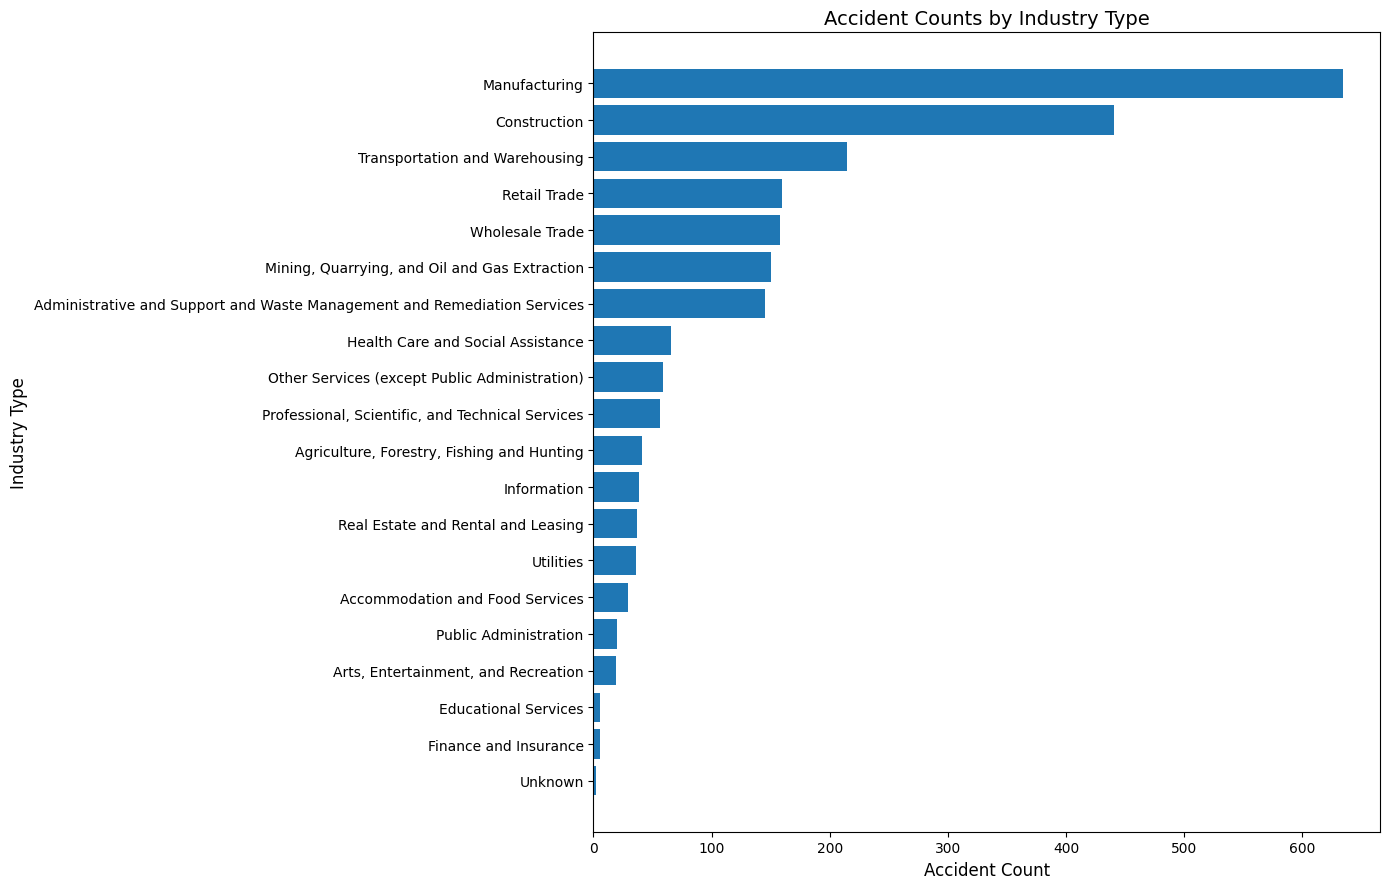

In [30]:
industry_summary_sorted = industry_summary.sort_values("accident_count", ascending=True)

plt.figure(figsize=(14, 9))
plt.barh(industry_summary_sorted["industry_type"], industry_summary_sorted["accident_count"])
plt.xlabel("Accident Count", fontsize=12)
plt.ylabel("Industry Type", fontsize=12)
plt.title("Accident Counts by Industry Type", fontsize=14)
plt.tight_layout()
plt.show()

### Accident Counts by Parish

In [10]:
parish_summary = (
    df.groupby("parish")
    .size()
    .reset_index(name="accident_count")
    .sort_values("accident_count", ascending=False)
)

parish_summary

,parish,accident_count
16,East Baton Rouge,215
25,Jefferson,174
35,Orleans,161
8,Caddo,133
9,Calcasieu,126
...,...,...
17,East Carroll,3
32,Madison,3
10,Caldwell,2
45,St. Helena,2


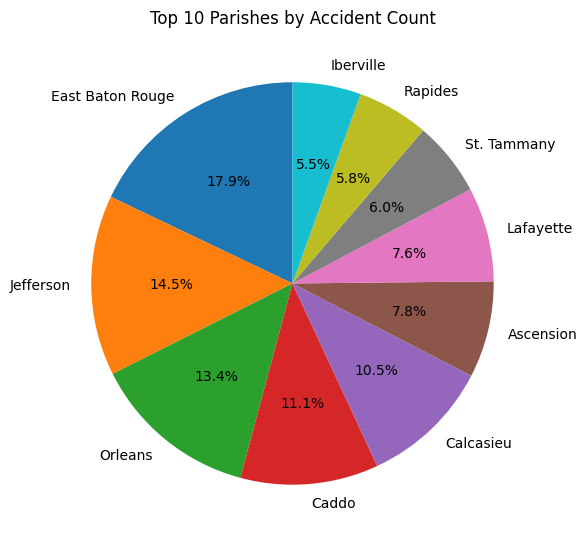

In [31]:
top_parishes = parish_summary.head(10)

plt.figure(figsize=(6, 6))
plt.pie(
    top_parishes["accident_count"],
    labels=top_parishes["parish"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Top 10 Parishes by Accident Count")
plt.tight_layout()
plt.show()

### Accident Counts by Industry and Parish

In [25]:
industry_parish_summary = (
    df.groupby(["parish", "industry_type"])
    .size()
    .reset_index(name="accident_count")
    .sort_values("accident_count", ascending=False)
)

industry_parish_summary.head(20)

,parish,industry_type,accident_count
121,East Baton Rouge,Manufacturing,53
117,East Baton Rouge,Construction,49
66,Caddo,Manufacturing,44
78,Calcasieu,Construction,40
182,Jefferson,Construction,38
266,Orleans,Construction,36
186,Jefferson,Manufacturing,35
79,Calcasieu,Manufacturing,27
18,Ascension,Manufacturing,25
311,Rapides,Manufacturing,25


In [26]:
industry_parish_pivot = industry_parish_summary.pivot(
    index="parish",
    columns="industry_type",
    values="accident_count"
).fillna(0)

industry_parish_pivot.head()

industry_type,Accommodation and Food Services,Administrative and Support and Waste Management and Remediation Services,"Agriculture, Forestry, Fishing and Hunting","Arts, Entertainment, and Recreation",Construction,Educational Services,Finance and Insurance,Health Care and Social Assistance,Information,Manufacturing,"Mining, Quarrying, and Oil and Gas Extraction",Other Services (except Public Administration),"Professional, Scientific, and Technical Services",Public Administration,Real Estate and Rental and Leasing,Retail Trade,Transportation and Warehousing,Unknown,Utilities,Wholesale Trade
parish,,,,,,,,,,,,,,,,,,,,
Acadia,0.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,11.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0
Allen,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,1.0,1.0
Ascension,2.0,5.0,0.0,0.0,22.0,0.0,0.0,0.0,1.0,25.0,3.0,7.0,5.0,0.0,1.0,2.0,14.0,0.0,0.0,6.0
Assumption,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
Avoyelles,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,7.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


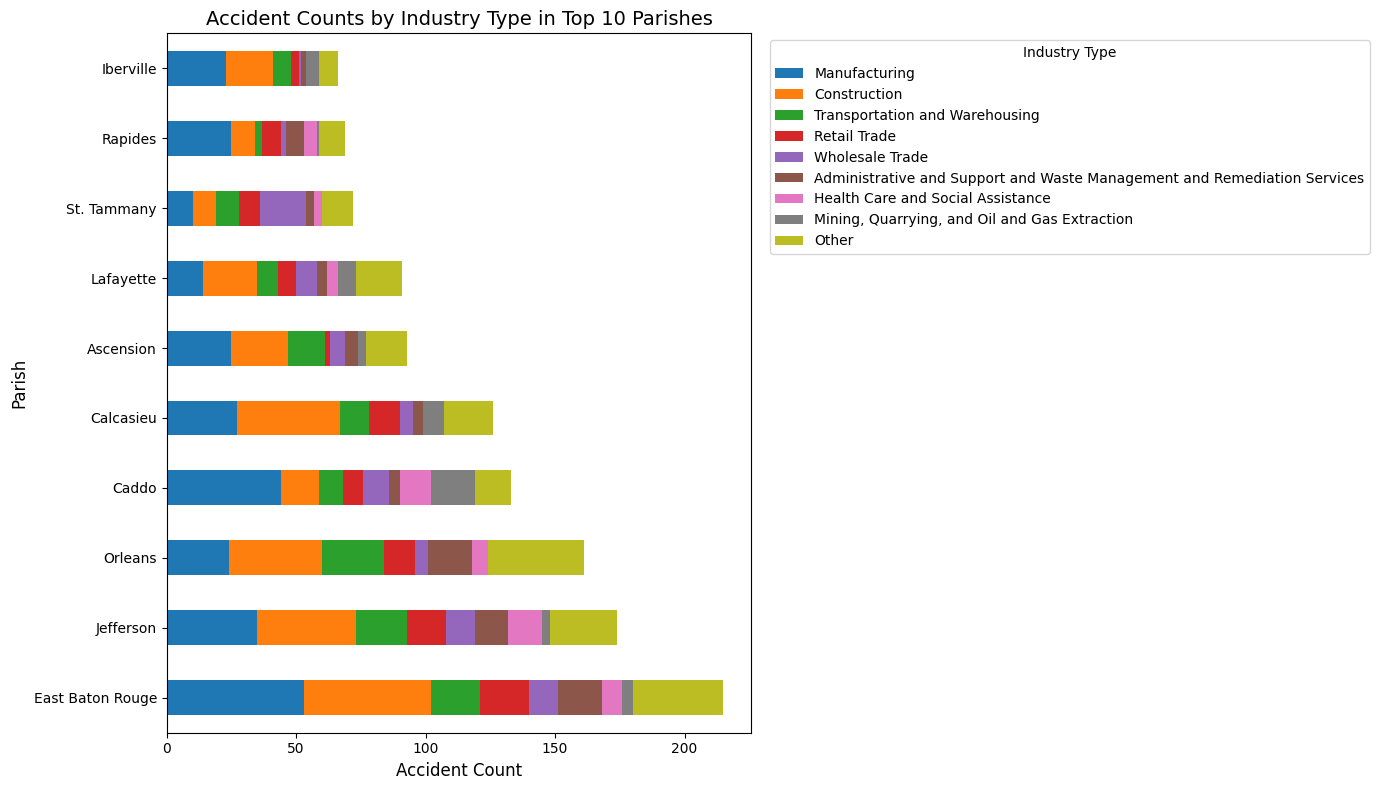

In [36]:
top_10_parishes = parish_summary.head(10)["parish"]
top_pivot = industry_parish_pivot.loc[top_10_parishes]

top_industries = top_pivot.sum().sort_values(ascending=False).head(8).index

top_pivot_clean = top_pivot[top_industries].copy()
top_pivot_clean["Other"] = top_pivot.drop(columns=top_industries).sum(axis=1)

top_pivot_clean.plot(kind="barh", stacked=True, figsize=(14, 8))

plt.xlabel("Accident Count", fontsize=12)
plt.ylabel("Parish", fontsize=12)
plt.title("Accident Counts by Industry Type in Top 10 Parishes", fontsize=14)
plt.legend(title="Industry Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()